# Qiskit QNP VQE implementation for CO$_2$

This notebook presents a simple Qiskit implementation of the QNP VQE ansatz <br>
https://iopscience.iop.org/article/10.1088/1367-2630/ac2cb3/meta <br>
The specific case considered here is the (4,4) active space of the CO$_2$ molecules. The simulation involves 8 qubits and 3 layers depth for a total of 18 parameters.<br> 
To simplify future simulations on harware, the VQE ansatz uses fixed parameters obtained from Quicksilver (the optimization itself could be challenging in the presence of noise).<br>
The exact estimation of the Hamiltonian on the QNP circuit reproduces within chemical accuracy the FCI reference energy.<br>

Set up quantum circuit

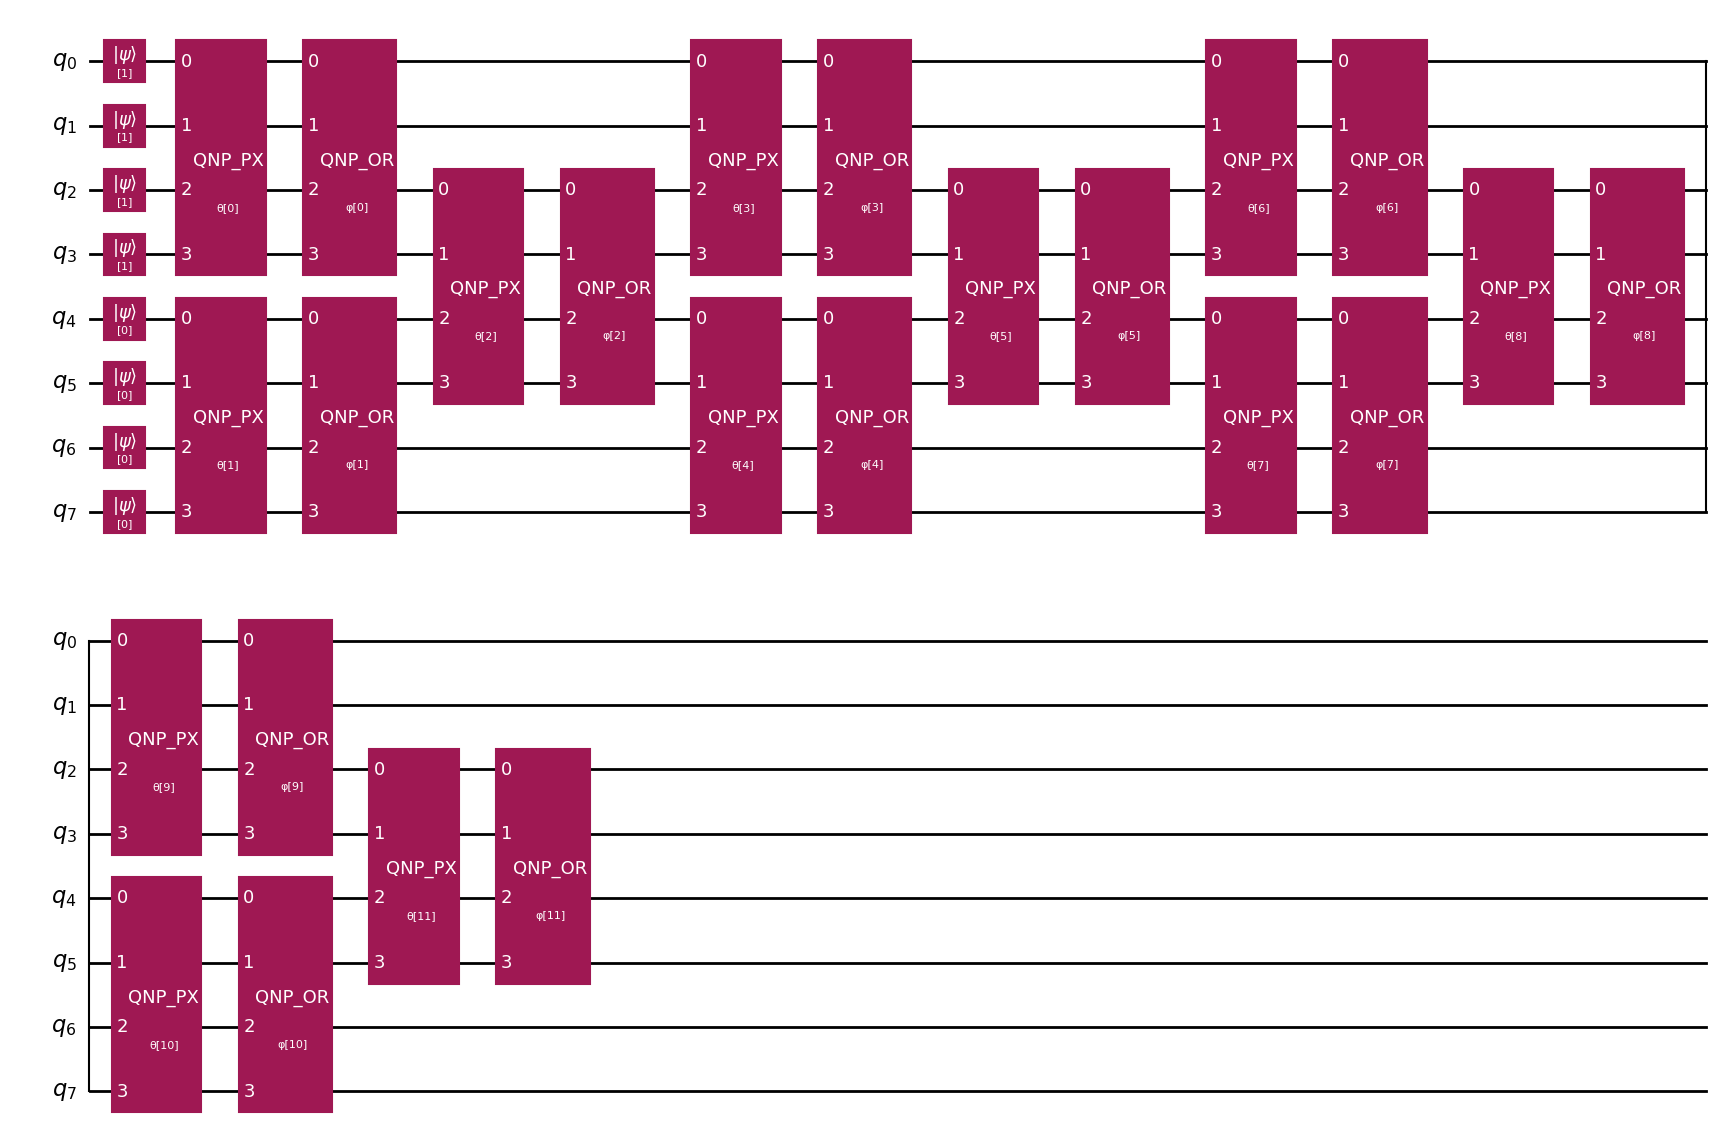

In [1]:
import numpy as np
import sys
sys.path.append('../qnp_utils')
from qnp_utils import count_QNP_params, initialize_HF, QNP_fabric
from qiskit.circuit import ParameterVector
from qiskit import QuantumCircuit

n_layers = 4
n_qbits = 8
intfile = '../../fullci_reference_pyscf/singlet/CO2integrals.npz'
integrals = np.load(intfile)
nelec = int(integrals['Nelec'])

n_theta, n_phi = count_QNP_params(n_qbits, n_layers)

theta = ParameterVector('θ', n_theta)
phi = ParameterVector('φ', n_phi)

qnp_circ = QuantumCircuit(n_qbits)
initialize_HF(qnp_circ,nelec)
QNP_fabric(qnp_circ, n_layers, theta, phi)

# Draw the main circuit
qnp_circ.draw('mpl')

Set up Hamiltonian 

In [2]:
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.quantum_info import SparsePauliOp
from qnp_utils import reorder_alphabeta_to_interleaved

#Load the active space integrals defining the Hamiltonian 
#integrals = np.load('../../reduced_active_space/CO2integrals.npz')
H0 = integrals['Ecore']
H1 = integrals['Hact']
H2 = integrals['Iact']
#nelec = int(integrals['Nelec'])

print(f"H0: {H0}")
print(f"H1 type: {type(H1)}, H1 shape {H1.shape}")
print(f"H2 type: {type(H2)}, H2 shape {H2.shape}")

#Setting up the electronic Hamiltonian from H1 and H2 integrals
hamiltonian = ElectronicEnergy.from_raw_integrals(H1, H2)
hamiltonian.nuclear_repulsion_energy = H0 # This is just a constant in the Hamiltonian


#Hamiltonian in second quantization
second_q_H = hamiltonian.second_q_op()

#Fermion to qubit mapping
mapper = JordanWignerMapper()
qubit_jw_H = mapper.map(second_q_H)

#Changing Pauli strings to interleaved order 
pauli_terms = qubit_jw_H.paulis  
coeffs = qubit_jw_H.coeffs
interleaved_pauli = reorder_alphabeta_to_interleaved(pauli_terms)
qubit_jw_H = SparsePauliOp.from_list(list(zip(interleaved_pauli, coeffs)))

H0: 0.0
H1 type: <class 'numpy.ndarray'>, H1 shape (4, 4)
H2 type: <class 'numpy.ndarray'>, H2 shape (4, 4, 4, 4)


Use Qiskit to compute the exact expectation value

/var/folders/8t/sc1bgt5j6lq9xbhs1x35vggm0000gn/T/ipykernel_25533/4089849261.py:8: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  exact_estimator = Estimator()


-25.762038672932906
Qiskit estimate of ground state energy (exact estimator): -25.762038672932906 Ha
Deviation from reference FCI: 7.926104217403918e-12 Ha
Deviation of Quicksilver:     7.702283255639486e-12 Ha


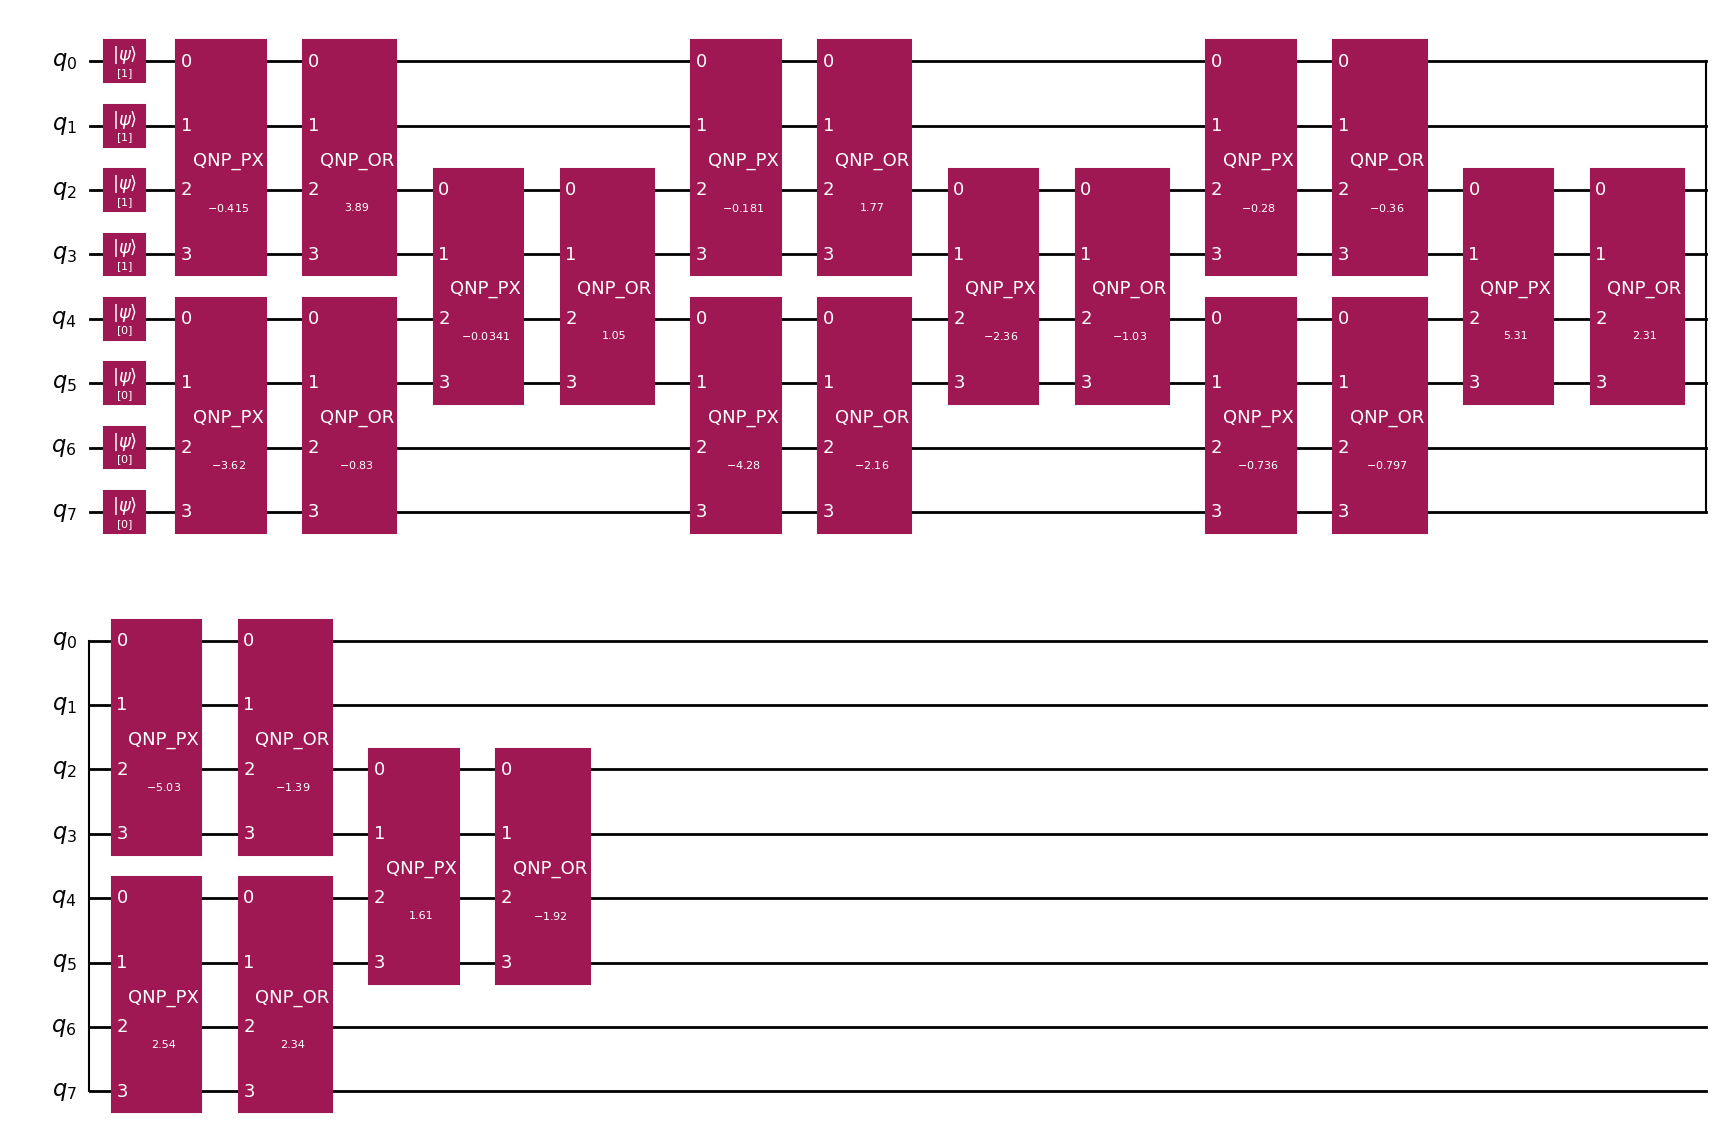

In [3]:
from qiskit.primitives import Estimator
from qiskit.circuit import Parameter, ParameterVector
from qnp_utils import assign_parameters_from_file

#Reference FCI value
E_FCI = integrals['Efci']

exact_estimator = Estimator()

parfile='optimized_params.txt'
qnp_fix_param = assign_parameters_from_file(parfile, qnp_circ, n_layers, theta, phi)

results=exact_estimator.run(qnp_fix_param, qubit_jw_H) 
qiskit_exact_GSenergy=results.result().values[0]+H0
print(qiskit_exact_GSenergy)

print(f"Qiskit estimate of ground state energy (exact estimator): {qiskit_exact_GSenergy} Ha")
print(f"Deviation from reference FCI: {qiskit_exact_GSenergy-E_FCI} Ha")
print("Deviation of Quicksilver:     7.702283255639486e-12 Ha")
qnp_fix_param.draw('mpl')